In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

# Introduction


*   The goal of this project is to predict developer salaries based on survey data from the Stack Overflow Developer Survey
*   An important part of the project is data preprocessing and feature engineering, due to poor quality data and missing values
* The project also aims to investigate which features have the greatest impact on the salary
* Several machine learning models were evaluated, including Linear Regression, Random Forest and Gradient Boosting Regressor



# Data Cleaning

In [ ]:
data1 = pd.read_csv('survey_results_public.csv')#,on_bad_lines='skip')

/tmp/ipykernel_926/274616350.py:1: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  data1 = pd.read_csv('survey_results_public.csv')


#### choosing columns for modeling

In [ ]:
print(list(data1.columns))

['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechEndorse_13_TEXT', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'TechOppose_15_TEXT', 'Industry', 'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'JobSatPoints_15_TEXT', 'AIThreat', 'NewRole', 'ToolCountWork', 'ToolCountPersona

In [ ]:
org_data = pd.DataFrame(data1, columns=['MainBranch','Age','EdLevel','Employment','WorkExp','YearsCode','DevType','OrgSize','RemoteWork','Industry','Country','LanguageHaveWorkedWith',
                                   'DatabaseHaveWorkedWith','PlatformHaveWorkedWith','WebframeHaveWorkedWith','DevEnvsHaveWorkedWith',
                                    'AIModelsHaveWorkedWith','ConvertedCompYearly'])

#### removing duplicates

In [ ]:
org_data = org_data.drop_duplicates()

In [ ]:
org_data = org_data[org_data['ConvertedCompYearly'].notna()]

#### dropping columns with more than 50% missing values

In [ ]:
org_data.isnull().sum()*100/(len(org_data))

,0
MainBranch,0.000000
Age,0.000000
EdLevel,0.070996
Employment,0.000000
WorkExp,1.996241
YearsCode,0.455210
DevType,0.000000
OrgSize,11.451242
RemoteWork,11.902276
Industry,3.817081


In [ ]:
org_data = org_data.drop(columns='AIModelsHaveWorkedWith',axis=1)

In [ ]:
org_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23945 entries, 0 to 49122
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   MainBranch              23945 non-null  object 
 1   Age                     23945 non-null  object 
 2   EdLevel                 23928 non-null  object 
 3   Employment              23945 non-null  object 
 4   WorkExp                 23467 non-null  float64
 5   YearsCode               23836 non-null  float64
 6   DevType                 23945 non-null  object 
 7   OrgSize                 21203 non-null  object 
 8   RemoteWork              21095 non-null  object 
 9   Industry                23031 non-null  object 
 10  Country                 23945 non-null  object 
 11  LanguageHaveWorkedWith  22119 non-null  object 
 12  DatabaseHaveWorkedWith  18474 non-null  object 
 13  PlatformHaveWorkedWith  17866 non-null  object 
 14  WebframeHaveWorkedWith  16603 non-null  obj

In [ ]:
org_data.head()

,MainBranch,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,OrgSize,RemoteWork,Industry,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,DevEnvsHaveWorkedWith,ConvertedCompYearly
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"Developer, mobile",20 to 99 employees,Remote,Fintech,Ukraine,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,Android Studio;Notepad++;Visual Studio;Visual ...,61256.0
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,2.0,10.0,"Developer, back-end",500 to 999 employees,"Hybrid (some in-person, leans heavy to flexibi...",Retail and Consumer Services,Netherlands,Java,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Spring Boot,IntelliJ IDEA;PyCharm;Visual Studio Code;Xcode,104413.0
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",10.0,12.0,"Developer, front-end",NaN,NaN,Software Development,Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Datadog;Firebase;npm;pnpm,Next.js;Node.js;React,Visual Studio Code,53061.0
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4.0,5.0,"Developer, back-end","10,000 or more employees",Remote,Retail and Consumer Services,Ukraine,Java;Kotlin;SQL,NaN,Amazon Web Services (AWS);Google Cloud,Spring Boot,NaN,36197.0
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",21.0,22.0,Engineering manager,NaN,NaN,Software Development,Ukraine,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Amazon Web Services (AWS);APT;Docker;Make;Mave...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery,Eclipse;IntelliJ IDEA;Jupyter Notebook/Jupyter...,60000.0


In [ ]:
# filling null values with median or mode
for col in ['WorkExp','YearsCode']:
    org_data[col] = org_data[col].fillna(org_data[col].median())

for col in ['EdLevel','OrgSize','RemoteWork','Industry']:
    org_data[col]= org_data[col].fillna(org_data[col].mode()[0])

# filling null values and splitting strings in a column into a list
listy = ['DevType','LanguageHaveWorkedWith','DatabaseHaveWorkedWith','PlatformHaveWorkedWith','WebframeHaveWorkedWith','DevEnvsHaveWorkedWith']

for col in listy:
    org_data[col] = org_data[col].fillna('Unknown')
    org_data[col] = org_data[col].str.split(';')

In [ ]:
org_data.head()

,MainBranch,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,OrgSize,RemoteWork,Industry,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,DevEnvsHaveWorkedWith,ConvertedCompYearly
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"[Developer, mobile]",20 to 99 employees,Remote,Fintech,Ukraine,"[Bash/Shell (all shells), Dart, SQL]","[Cloud Firestore, PostgreSQL]","[Amazon Web Services (AWS), Cloudflare, Fireba...",[Unknown],"[Android Studio, Notepad++, Visual Studio, Vis...",61256.0
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,2.0,10.0,"[Developer, back-end]",500 to 999 employees,"Hybrid (some in-person, leans heavy to flexibi...",Retail and Consumer Services,Netherlands,[Java],"[Dynamodb, MongoDB]","[Amazon Web Services (AWS), Datadog, Docker, H...",[Spring Boot],"[IntelliJ IDEA, PyCharm, Visual Studio Code, X...",104413.0
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",10.0,12.0,"[Developer, front-end]",20 to 99 employees,Remote,Software Development,Ukraine,"[Dart, HTML/CSS, JavaScript, TypeScript]","[MongoDB, MySQL, PostgreSQL]","[Datadog, Firebase, npm, pnpm]","[Next.js, Node.js, React]",[Visual Studio Code],53061.0
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4.0,5.0,"[Developer, back-end]","10,000 or more employees",Remote,Retail and Consumer Services,Ukraine,"[Java, Kotlin, SQL]",[Unknown],"[Amazon Web Services (AWS), Google Cloud]",[Spring Boot],[Unknown],36197.0
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",21.0,22.0,[Engineering manager],20 to 99 employees,Remote,Software Development,Ukraine,"[C, C#, C++, Delphi, HTML/CSS, Java, JavaScrip...","[Elasticsearch, Microsoft SQL Server, MySQL, O...","[Amazon Web Services (AWS), APT, Docker, Make,...","[Angular, ASP.NET, ASP.NET Core, Flask, jQuery]","[Eclipse, IntelliJ IDEA, Jupyter Notebook/Jupy...",60000.0


In [ ]:
# printing info about each column - number of unique values
for col in org_data.columns:
    if col in listy:
        uni = org_data[col].explode().unique().size
    else:
        uni = org_data[col].unique().size
    print(f"\nName of the column: {col}")
    print(f"Number of unique values: {uni}")
       # print(data[col].explode().value_counts())
    if uni <10:
        print(org_data[col].value_counts())


Name of the column: MainBranch
Number of unique values: 6
MainBranch
I am a developer by profession                                                                20193
I am not primarily a developer, but I write code sometimes as part of my work/studies          2187
I used to be a developer by profession, but no longer am                                        498
I work with developers or my work supports developers but am not a developer by profession      390
I am learning to code                                                                           363
I code primarily as a hobby                                                                     314
Name: count, dtype: int64

Name of the column: Age
Number of unique values: 7
Age
25-34 years old      8598
35-44 years old      7581
45-54 years old      3428
18-24 years old      2601
55-64 years old      1387
65 years or older     328
Prefer not to say      22
Name: count, dtype: int64

Name of the column: EdLevel
Number of u

# Feature Engineering

#### reducing cardinality

In [ ]:
org_data['RemoteWork'] = org_data['RemoteWork'].replace(['Hybrid (some remote, leans heavy to in-person)','Hybrid (some in-person, leans heavy to flexibility)'],'Hybrid')
org_data=  org_data[org_data['RemoteWork'].isin(['Hybrid','In-person','Remote'])]
org_data = org_data[org_data['MainBranch']=='I am a developer by profession']
org_data = org_data[org_data['Employment'].isin(['Employed','Independent contractor, freelancer, or self-employed','Student'])]
org_data = org_data[org_data['Age']!= 'Prefer not to say']
org_data = org_data[org_data['OrgSize']!= 'I don’t know']
org_data['OrgSize'] = org_data['OrgSize'].replace('Just me - I am a freelancer, sole proprietor, etc.','Just me')

In [ ]:
org_data.head()

,MainBranch,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,OrgSize,RemoteWork,Industry,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,DevEnvsHaveWorkedWith,ConvertedCompYearly
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"[Developer, mobile]",20 to 99 employees,Remote,Fintech,Ukraine,"[Bash/Shell (all shells), Dart, SQL]","[Cloud Firestore, PostgreSQL]","[Amazon Web Services (AWS), Cloudflare, Fireba...",[Unknown],"[Android Studio, Notepad++, Visual Studio, Vis...",61256.0
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,2.0,10.0,"[Developer, back-end]",500 to 999 employees,Hybrid,Retail and Consumer Services,Netherlands,[Java],"[Dynamodb, MongoDB]","[Amazon Web Services (AWS), Datadog, Docker, H...",[Spring Boot],"[IntelliJ IDEA, PyCharm, Visual Studio Code, X...",104413.0
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",10.0,12.0,"[Developer, front-end]",20 to 99 employees,Remote,Software Development,Ukraine,"[Dart, HTML/CSS, JavaScript, TypeScript]","[MongoDB, MySQL, PostgreSQL]","[Datadog, Firebase, npm, pnpm]","[Next.js, Node.js, React]",[Visual Studio Code],53061.0
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4.0,5.0,"[Developer, back-end]","10,000 or more employees",Remote,Retail and Consumer Services,Ukraine,"[Java, Kotlin, SQL]",[Unknown],"[Amazon Web Services (AWS), Google Cloud]",[Spring Boot],[Unknown],36197.0
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",21.0,22.0,[Engineering manager],20 to 99 employees,Remote,Software Development,Ukraine,"[C, C#, C++, Delphi, HTML/CSS, Java, JavaScrip...","[Elasticsearch, Microsoft SQL Server, MySQL, O...","[Amazon Web Services (AWS), APT, Docker, Make,...","[Angular, ASP.NET, ASP.NET Core, Flask, jQuery]","[Eclipse, IntelliJ IDEA, Jupyter Notebook/Jupy...",60000.0


#### one-hot encoding

In [ ]:
age_order = {
    '25-34 years old':0,
    '35-44 years old':1,
    '45-54 years old':2,
    '18-24 years old':3,
    '55-64 years old':4,
    '65 years or older':5
}
orgsize_order = {
    'Just me':0,
    'Less than 20 employees':1,
    '20 to 99 employees':2,
    '100 to 499 employees':3,
    '500 to 999 employees':4,
    '1,000 to 4,999 employees':5,
    '5,000 to 9,999 employees':6,
    '10,000 or more employees':7
}

edLevel_order = {
    'Primary/elementary school':0,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)':1,
    'Some college/university study without earning a degree':2,
    'Associate degree (A.A., A.S., etc.)':3,
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)':4,
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)':5,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)':6,
    'Other (please specify):':2
}

employment_order = {
    'Student':0,
    'Employed':1,
    'Independent contractor, freelancer, or self-employed':2
}

remote_order = {
    'In-person':0,
    'Hybrid':1,
    'Remote':2
}

In [ ]:
data = org_data.copy()
data['Age'] = data['Age'].map(age_order)
data['OrgSize'] = data['OrgSize'].map(orgsize_order)
data['EdLevel'] = data['EdLevel'].map(edLevel_order)
data['Employment'] = data['Employment'].map(employment_order)
data['RemoteWork'] = data['RemoteWork'].map(remote_order)

In [ ]:
# taking top 10 most common values from each column that has a lot of values
topCountries = data['Country'].value_counts().head(10).index
topIndustries = data['Industry'].value_counts().head(10).index

topLanguages = data['LanguageHaveWorkedWith'].explode().value_counts().head(10).index
topDatabases = data['DatabaseHaveWorkedWith'].explode().value_counts().head(10).index
topPlatforms = data['PlatformHaveWorkedWith'].explode().value_counts().head(10).index
topWebframes = data['WebframeHaveWorkedWith'].explode().value_counts().head(10).index
topDevEnvs = data['DevEnvsHaveWorkedWith'].explode().value_counts().head(10).index
topDevTypes = data['DevType'].explode().value_counts().head(10).index

In [ ]:
data.head()

,MainBranch,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,OrgSize,RemoteWork,Industry,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,DevEnvsHaveWorkedWith,ConvertedCompYearly
0,I am a developer by profession,0,5,1,8.0,14.0,"[Developer, mobile]",2,2,Fintech,Ukraine,"[Bash/Shell (all shells), Dart, SQL]","[Cloud Firestore, PostgreSQL]","[Amazon Web Services (AWS), Cloudflare, Fireba...",[Unknown],"[Android Studio, Notepad++, Visual Studio, Vis...",61256.0
1,I am a developer by profession,0,3,1,2.0,10.0,"[Developer, back-end]",4,1,Retail and Consumer Services,Netherlands,[Java],"[Dynamodb, MongoDB]","[Amazon Web Services (AWS), Datadog, Docker, H...",[Spring Boot],"[IntelliJ IDEA, PyCharm, Visual Studio Code, X...",104413.0
2,I am a developer by profession,1,4,2,10.0,12.0,"[Developer, front-end]",2,2,Software Development,Ukraine,"[Dart, HTML/CSS, JavaScript, TypeScript]","[MongoDB, MySQL, PostgreSQL]","[Datadog, Firebase, npm, pnpm]","[Next.js, Node.js, React]",[Visual Studio Code],53061.0
3,I am a developer by profession,1,4,1,4.0,5.0,"[Developer, back-end]",7,2,Retail and Consumer Services,Ukraine,"[Java, Kotlin, SQL]",[Unknown],"[Amazon Web Services (AWS), Google Cloud]",[Spring Boot],[Unknown],36197.0
4,I am a developer by profession,1,5,2,21.0,22.0,[Engineering manager],2,2,Software Development,Ukraine,"[C, C#, C++, Delphi, HTML/CSS, Java, JavaScrip...","[Elasticsearch, Microsoft SQL Server, MySQL, O...","[Amazon Web Services (AWS), APT, Docker, Make,...","[Angular, ASP.NET, ASP.NET Core, Flask, jQuery]","[Eclipse, IntelliJ IDEA, Jupyter Notebook/Jupy...",60000.0


In [ ]:
# transforming top values into separate 1/0 columns
temp = ['LanguageHaveWorkedWith','DatabaseHaveWorkedWith','PlatformHaveWorkedWith','WebframeHaveWorkedWith','DevEnvsHaveWorkedWith','DevType']
top_list = list(topLanguages) + list(topDatabases) + list(topPlatforms) + list(topWebframes) + list(topDevEnvs) + list(topDevTypes)
mapping_top = {
    'LanguageHaveWorkedWith':topLanguages,
    'DatabaseHaveWorkedWith': topDatabases,
    'PlatformHaveWorkedWith': topPlatforms,
    'WebframeHaveWorkedWith':topWebframes,
    'DevEnvsHaveWorkedWith':topDevEnvs,
    'DevType': topDevTypes
}

for col,items in mapping_top.items():
    rep = col.replace('HaveWorkedWith','')
    for item in items:
        new_name = f'{rep}_{item}'
        data[new_name] = data[col].str.contains(item, na=False, regex=False).astype(int)

In [ ]:
# removing old columns
data = data.drop(temp, axis=1)

In [ ]:
# transforming top values into separate columns, other values go to the column 'Other'
data['Country_New']= data['Country'].apply(lambda x: x if x in topCountries else 'Other')
data['Industries_New']= data['Industry'].apply(lambda x: x if x in topIndustries else 'Other')

country_dummies = pd.get_dummies(data['Country_New'], prefix='Country', drop_first=True)
data = pd.concat([data,country_dummies],axis=1)

ind_dummies = pd.get_dummies(data['Industries_New'], prefix='Industry', drop_first=True)
data = pd.concat([data,ind_dummies],axis=1)

# removing old columns
data = data.drop(['Country','Country_New','Industry','Industries_New','MainBranch'],axis=1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17265 entries, 0 to 49121
Data columns (total 88 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Age                                                           17265 non-null  int64  
 1   EdLevel                                                       17265 non-null  int64  
 2   Employment                                                    17265 non-null  int64  
 3   WorkExp                                                       17265 non-null  float64
 4   YearsCode                                                     17265 non-null  float64
 5   OrgSize                                                       17265 non-null  int64  
 6   RemoteWork                                                    17265 non-null  int64  
 7   ConvertedCompYearly                                           17265 non-

In [ ]:
data = data.drop(columns=['Industry_Other:','DevEnvs_Unknown','Database_Unknown','Platform_Unknown',
                          'Webframe_Unknown'])

In [ ]:
data.head()

,Age,EdLevel,Employment,WorkExp,YearsCode,OrgSize,RemoteWork,ConvertedCompYearly,Language_JavaScript,Language_HTML/CSS,...,Country_United States of America,Industry_Fintech,Industry_Government,Industry_Healthcare,"Industry_Internet, Telecomm or Information Services",Industry_Manufacturing,Industry_Other,Industry_Retail and Consumer Services,Industry_Software Development,"Industry_Transportation, or Supply Chain"
0,0,5,1,8.0,14.0,2,2,61256.0,0,0,...,False,True,False,False,False,False,False,False,False,False
1,0,3,1,2.0,10.0,4,1,104413.0,0,0,...,False,False,False,False,False,False,False,True,False,False
2,1,4,2,10.0,12.0,2,2,53061.0,1,1,...,False,False,False,False,False,False,False,False,True,False
3,1,4,1,4.0,5.0,7,2,36197.0,0,0,...,False,False,False,False,False,False,False,True,False,False
4,1,5,2,21.0,22.0,2,2,60000.0,1,1,...,False,False,False,False,False,False,False,False,True,False


#### deleting outliers

In [ ]:
Q1 = data['ConvertedCompYearly'].quantile(0.25)
Q3 = data['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print(f'Removing rows with salary > {upper} and < {lower}')

data = data[data['ConvertedCompYearly']<=upper]
data = data[data['ConvertedCompYearly']>=lower]

Removing rows with salary > 252352.5 and < -84587.5


# EDA

#### Salary distribution

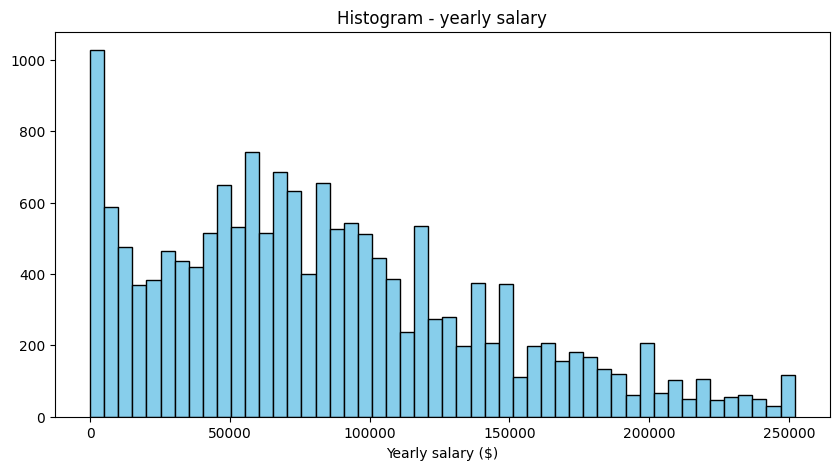

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(data['ConvertedCompYearly'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram - yearly salary')
plt.xlabel('Yearly salary ($)')
plt.show()

**Conclusions**
*   **right-skwed distribiution: most people earn low salary, only a small number have high income**
*   **as salary increases, the number of people decreses**
*   **most common salaries are in between 45-80k $**

#### Salary vs Age

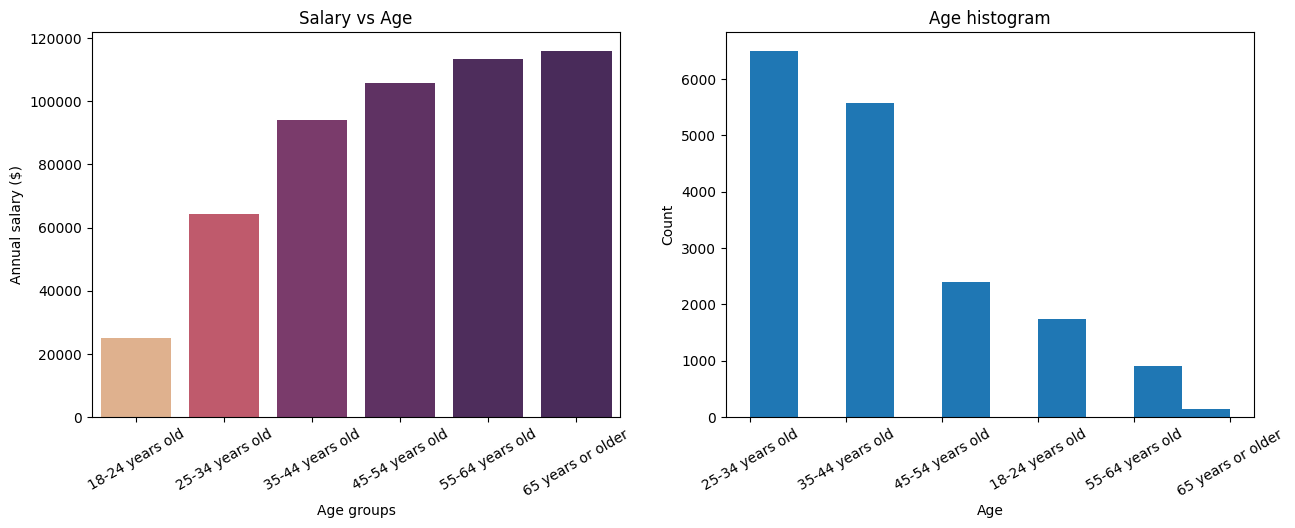

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
df_grouped = org_data.groupby('Age', as_index=False)['ConvertedCompYearly'].median()
sns.barplot(df_grouped,x='Age', y ='ConvertedCompYearly', hue='ConvertedCompYearly',palette='flare',legend=False)
plt.xlabel('Age groups')
plt.xticks(rotation=30)
plt.ylabel('Annual salary ($)')
plt.title('Salary vs Age')

plt.subplot(1,2,2)
plt.hist(org_data['Age'])
plt.xticks(rotation=30)
plt.title('Age histogram')
plt.ylabel('Count')
plt.xlabel('Age')
plt.show()

**Conclusions**
*   **clear upward trend (strong positive correlation): salary increses with age**
*   **the highest difference is between age groups: 18-24 and 25-34 years old due to career progression**
*   **between age groups 55-64 and 65+ years old trend starts to flatten**
* **the age distribution is right-skewed (more data in younger/middle ages, fewer in older ages). The dataset is dominated by people aged 25–34 and 35–44**

#### Top Developer Types by Salary

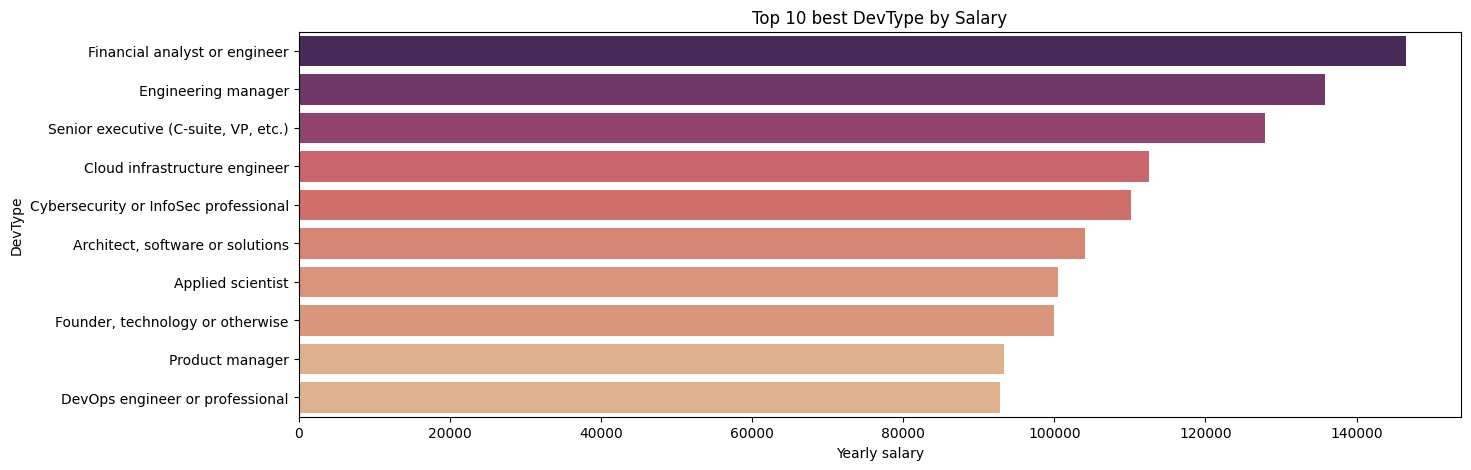

In [ ]:
plt.figure(figsize=(15,5))
org_data2 = org_data.copy()
org_data2['DevType'] = org_data['DevType'].apply(lambda x: " ".join(x))
df_grouped2 = org_data2.groupby('DevType', as_index=False)['ConvertedCompYearly'].median().sort_values(by='ConvertedCompYearly',ascending=False).head(10)
sns.barplot(df_grouped2,y='DevType', x ='ConvertedCompYearly', hue='ConvertedCompYearly',palette='flare',legend=False,orient='h')
plt.ylabel('DevType')
plt.xlabel('Yearly salary')
plt.title('Top 10 best DevType by Salary')
plt.show()

**Conclusions**
*   **highest-paying role are:**
1.   Financial analyst or engineer (~145k $)

2.    Engineering manager (~135k $)

3.   Senior executive (~130k $)

**these roles require technical expertise combined with strong leadership skills**

*   **other high-paying roles (cloud, security, architecture) require specialized technical skills and expertise as well**
*   **the salaries for the other roles are quite similar to each other, mostly falling within the range of 90k to 110k $**

#### Top Countries by Salary

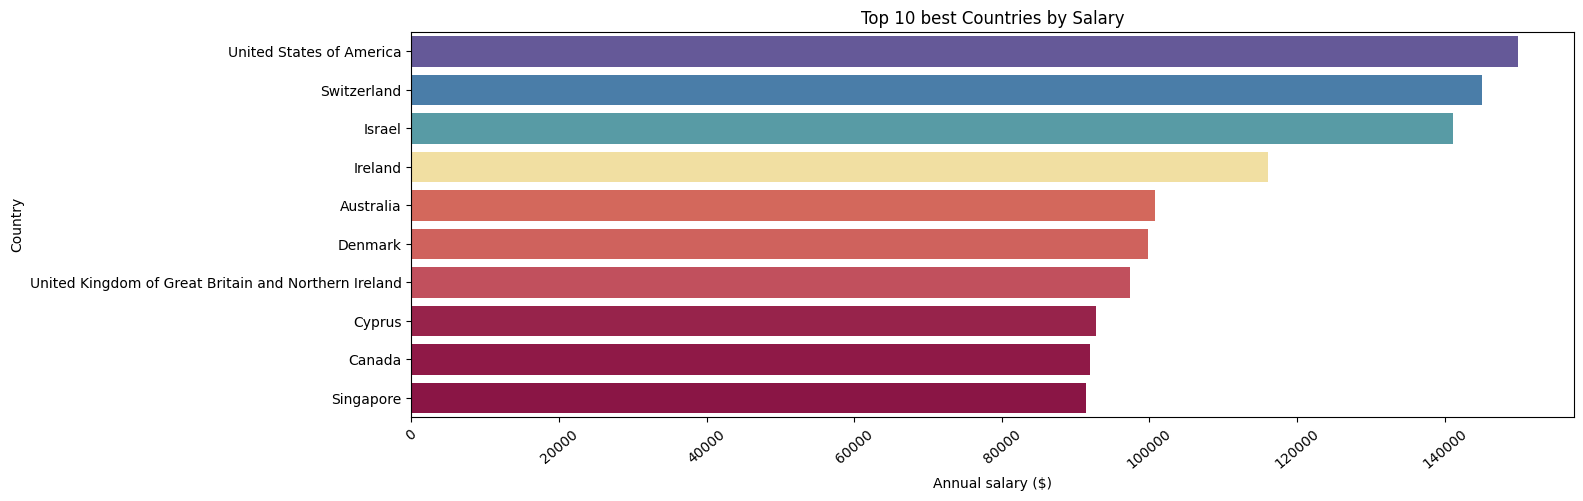

In [ ]:
val_counts = org_data['Country'].value_counts()
countries_temp = val_counts[val_counts>15].index # countries that accoured at least 16 times

plt.figure(figsize=(15,5))
df_grouped = org_data[org_data['Country'].isin(countries_temp)].groupby('Country', as_index=False)['ConvertedCompYearly'].median().sort_values(by='ConvertedCompYearly',ascending=False).head(10)
sns.barplot(df_grouped,y='Country', x ='ConvertedCompYearly', hue='ConvertedCompYearly',palette='Spectral',legend=False,orient='h')
plt.ylabel('Country')
plt.xticks(rotation=40,fontsize=10)
plt.xlabel('Annual salary ($)')
plt.title('Top 10 best Countries by Salary')
plt.show()

**Conclusions**
*   **the highest salary are observed in United States, Switzerland and Israel, at around 140k $**
*   **there is a visible gap between top 3 best countries and the rest**

*   **salaries in the remaining countries are relatively similar, generally ranging from 90k to 100k $**
*   **most of the countries in the ranking are highly developed economies**

#### Salary vs Work Experience

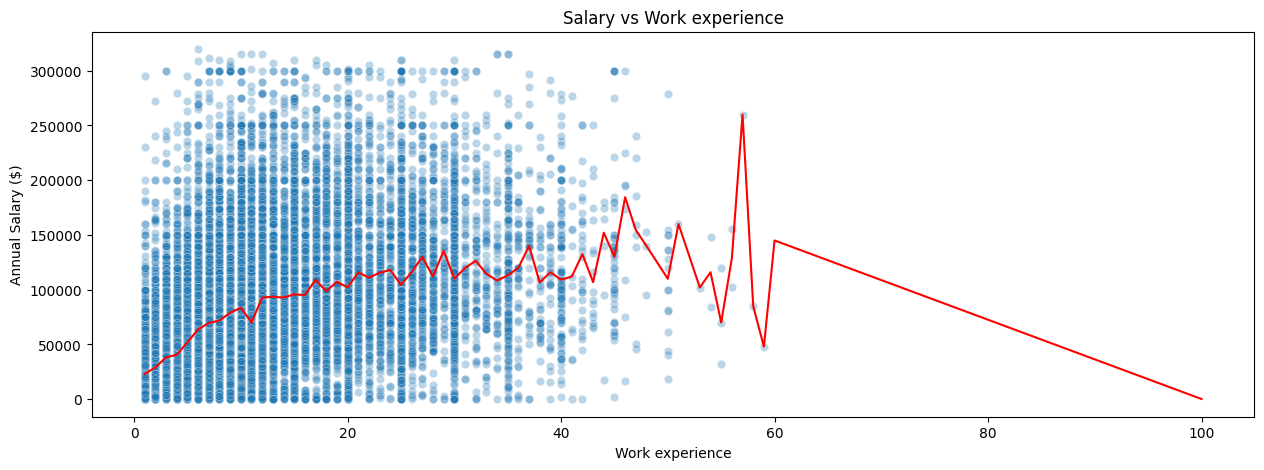

In [ ]:
plt.figure(figsize=(15,5))
filtered = org_data.groupby('WorkExp', as_index=False)['ConvertedCompYearly'].median()
org_data = org_data[org_data['ConvertedCompYearly']<320000]
org_data = org_data[org_data['WorkExp']<60]
sns.scatterplot(data=org_data, x='WorkExp', y='ConvertedCompYearly',alpha=0.3)
#sns.regplot(data=org_data, x='WorkExp',y='ConvertedCompYearly',color='r',scatter=False)
plt.plot(filtered['WorkExp'], filtered['ConvertedCompYearly'], color='r')
plt.xlabel('Work experience')
plt.ylabel('Annual Salary ($)')
plt.title('Salary vs Work experience')
plt.show()

**Conclusions**
*   **there is a positive relationship between work experience and salary, especially during the first 10 years**
* **between 1st and 10th year median salary tripples, reflecting carrer growth**
*   **after 10 years, upward trend continues, but becomes more gradual**
*   **after around 25 years, salaries tend to stabilize, with some fluctuations**
*   **beyond 45 years salary is irregular due to fewer observations and possible data inconsistencies**

In [ ]:
org_data['EdLevel'] = org_data['EdLevel'].replace('Master’s degree (M.A., M.S., M.Eng., MBA, etc.)','Master’s degree')
org_data['EdLevel'] = org_data['EdLevel'].replace('Bachelor’s degree (B.A., B.S., B.Eng., etc.)','Bachelor’s degree')
org_data['EdLevel'] = org_data['EdLevel'].replace('Professional degree (JD, MD, Ph.D, Ed.D, etc.)','Professional degree')
org_data['EdLevel'] = org_data['EdLevel'].replace('Other (please specify):','Other')
org_data['EdLevel'] = org_data['EdLevel'].replace('Some college/university study without earning a degree','College study without earning a degree')
org_data['EdLevel'] = org_data['EdLevel'].replace('Associate degree (A.A., A.S., etc.)','Associate degree')
org_data['EdLevel'] = org_data['EdLevel'].replace('Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                                  'Secondary school')
order_edu = [
    'Primary/elementary school',
    'Secondary school',
    'College study without earning a degree',
    'Associate degree',
    'Bachelor’s degree',
    'Master’s degree',
    'Professional degree',
    'Other']

#### Salary vs Education

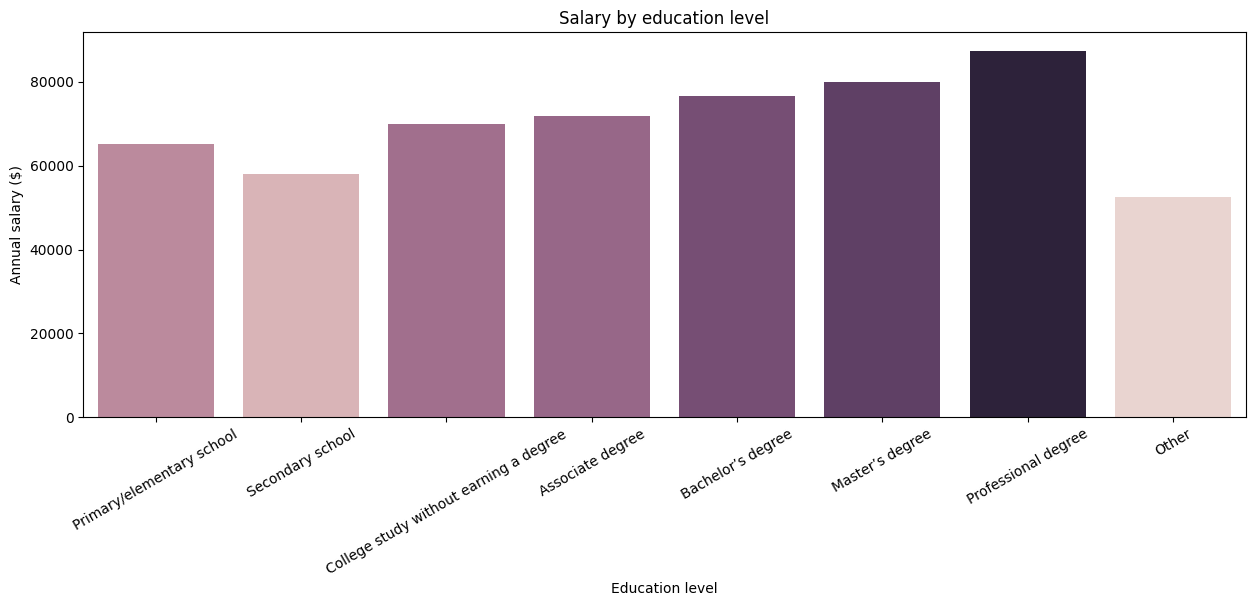

In [ ]:
plt.figure(figsize=(15,5))
filtered = org_data.groupby('EdLevel', as_index=False)['ConvertedCompYearly'].median()
sns.barplot(data=filtered, x='EdLevel', y='ConvertedCompYearly',order=order_edu,hue='ConvertedCompYearly',legend=False)
plt.xticks(rotation=30)
plt.xlabel('Education level')
plt.ylabel('Annual salary ($)')
plt.title('Salary by education level')
plt.show()

In [ ]:
filtered

,EdLevel,ConvertedCompYearly
0,Associate degree,71749.5
1,Bachelor’s degree,76570.0
2,College study without earning a degree,70000.0
3,Master’s degree,80000.0
4,Other,52530.0
5,Primary/elementary school,65268.5
6,Professional degree,87462.0
7,Secondary school,58007.0


**Conclusions**
*   **there is a positive relationship between education level and salary**
*   **the data suggests that higher education leads to higher salaries**
*   **the highest salaries are observed for professional and master's degrees**
*   **people with a Bachelor's degree earn about 18k  more than those with secondary school education, while those with a Professional degree earn almost $30k more**



In [ ]:
data['ConvertedCompYearly'].describe()

,ConvertedCompYearly
count,16610.000000
mean,83859.114389
std,58245.329899
min,1.000000
25%,40000.000000
50%,75410.000000
75%,118593.000000
max,252000.000000


In [ ]:
data.columns[data.isna().any()]

Index([], dtype='object')

In [ ]:
print(f'Number of rows: {data.shape[0]} \nNumber of columns : {data.shape[1]}')

Number of rows: 16610 
Number of columns : 83


#### Variables most correlated with salary

Axes(0.125,0.11;0.775x0.77)


Text(0.5, 0, 'Correlation')

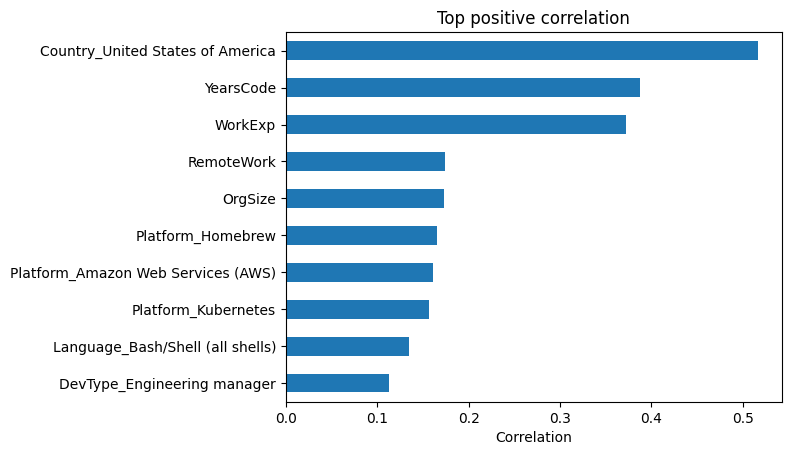

In [ ]:
cor = data.drop(columns='ConvertedCompYearly').corrwith(data['ConvertedCompYearly'])
print(cor.sort_values(ascending=True).tail(10).plot(kind='barh'))
plt.title('Top positive correlation')
plt.xlabel('Correlation')

*   **being located in the United States shows the strongest positive correlation with salary (~0.5)**
*   **years of coding experience (YearsCode) and work experience (WorkExp) are higly correlated (~0.39 and ~0.36), suggesting that more experience leads to higher salaries. However, these two variables might be higly correlated, which has to be checked to avoid multicollinearity in the model**
*   **remote work, organization size and the other variables have lower correlations, indicating some impact but less than experience or location in the USA**

Axes(0.125,0.11;0.775x0.77)


Text(0.5, 0, 'Correlation')

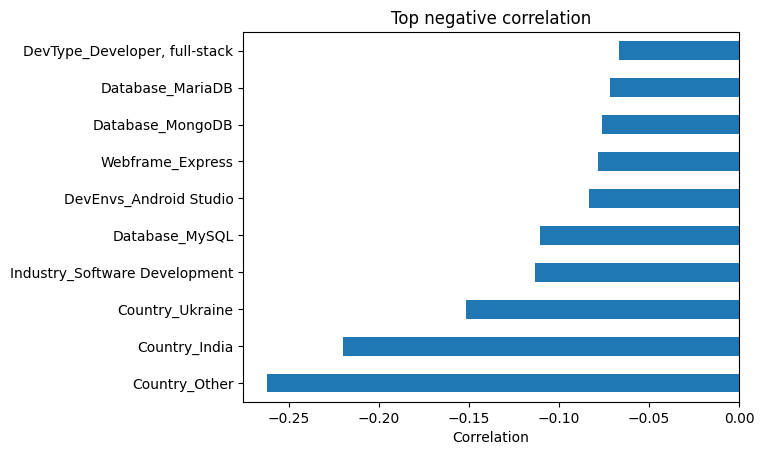

In [ ]:
print(cor.sort_values(ascending=True).head(10).plot(kind='barh'))
plt.title('Top negative correlation')
plt.xlabel('Correlation')

*   **not being located in the most common countries shows the strongest negative correlation with the salary**
*   **working in India or Ukraine are another negatively correlated features**
* **other variables show relatively low correlations, which suggests they have less consistent impact on salary compared to mentioned above features**

In [ ]:
data['WorkExp'].corr(data['YearsCode'])
# due to high correlation between Work Experience and YearsCode i'm deleting one of the columns to avoid multicorrelation

np.float64(0.8854387184199839)

In [ ]:
data = data.drop(columns='YearsCode')

# Modeling

## Baseline model

In [ ]:
from sklearn.dummy import DummyRegressor

In [ ]:
X = data.drop(columns='ConvertedCompYearly')
y = data['ConvertedCompYearly']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print(f'Size of the training set: {X_train.shape}')
print(f'Size of the testing set: {X_test.shape}')

Size of the training set: (13288, 81)
Size of the testing set: (3322, 81)


In [ ]:
results = pd.DataFrame(columns=['Model','R2 train','R2 test', 'MAE test','RMSE test'])

In [ ]:
def build_model(model,model_name, X_train, X_test, y_train, y_test,chart=0):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    evaluation_model(model,model_name,X_train,X_test,y_train,y_test,y_pred_train,y_pred_test)
    if chart:
        actual_predicted_plot(y_test, y_pred_test)
    #return model

In [ ]:
def evaluation_model(model,model_name,X_train,X_test,y_train,y_test,y_pred_train,y_pred_test):
  r2_train = r2_score(y_train, y_pred_train)
  r2_test = r2_score(y_test, y_pred_test)
  mae_train = mean_absolute_error(y_train, y_pred_train)
  mae_test = mean_absolute_error(y_test, y_pred_test)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
  print(f'--- Model -> {model_name}---')
  print(f'Evaluation - Training set')
  print(f'R2 score : {r2_train:.2f}')
  print(f'MAE score : {mae_train:,.2f} $')
  print(f'\nEvaluation - Test set')
  print(f'R2 score : {r2_test:.2f}')
  print(f'MAE score : {mae_test:,.2f} $')
  results.loc[len(results)] = {'Model':model_name,'R2 train': np.round(r2_train,2),
                               'R2 test':np.round(r2_test,2), 'MAE test':np.round(mae_test,2),
                               'RMSE test': np.round(rmse_test,2)}
  return results

In [ ]:
def actual_predicted_plot(y_test, y_pred_test):
  plt.figure(figsize=(15,5))
  plt.subplot(1,2,1)
  plt.scatter(y_test, y_pred_test, alpha=0.5)
  plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--' )
  plt.xlabel('Actual salary ($)')
  plt.ylabel('Predicted salary ($)')
  plt.title('Actual vs Predicted salary')
  plt.subplot(1,2,2)
  residuals = y_test - y_pred_test
  plt.scatter(y_pred_test, residuals,alpha=0.5)
  plt.axhline(y=0,color='r')
  plt.title('Residual plot')
  plt.xlabel('Predicted salary ($)')
  plt.ylabel('Residuals ($)')

In [ ]:
baseline = DummyRegressor(strategy='median')
build_model(baseline,'Baseline', X_train, X_test, y_train, y_test)

--- Model -> Baseline---
Evaluation - Training set
R2 score : -0.02
MAE score : 46,225.59 $

Evaluation - Test set
R2 score : -0.03
MAE score : 46,954.58 $


## Linear Regression

In [ ]:
model = LinearRegression()
build_model(model,'Linear Regression', X_train, X_test, y_train, y_test)

--- Model -> Linear Regression---
Evaluation - Training set
R2 score : 0.52
MAE score : 29,814.24 $

Evaluation - Test set
R2 score : 0.53
MAE score : 30,022.73 $


#### Top highest and lowest coefficients

In [ ]:
df_coef = pd.DataFrame(np.round(model.coef_,2),index= X.columns, columns=['Coef'])

In [ ]:
df_coef.sort_values(by='Coef', ascending=False).head(10)

,Coef
Country_United States of America,94311.23
Country_United Kingdom of Great Britain and Northern Ireland,57872.52
Country_Canada,51793.02
Country_Netherlands,44606.18
Country_Germany,42701.04
Country_France,28456.62
Country_Other,25633.80
DevType_Engineering manager,25575.72
Country_Poland,25402.36
"DevType_Architect, software or solutions",9163.81


* **location has a very stronger effect on the salary, with the USA having the highest positive coefficient (94k $)**

* **the second top-tier countries for salary are Canada, Netherlands and Germany (42-57k $)**
* **engineering manager roles show the strongest positive influence on salary**

In [ ]:
df_coef.sort_values(by='Coef', ascending=False).tail(10)

,Coef
Language_HTML/CSS,-3620.72
Database_MongoDB,-3880.75
Industry_Other,-4593.61
Database_MariaDB,-4643.74
Webframe_Express,-5088.19
Webframe_jQuery,-5157.30
Industry_Manufacturing,-5171.04
Age,-5505.47
DevEnvs_Android Studio,-5544.15
Database_MySQL,-7725.54


*   **several technologies (such as MySQL, jQuery, Express, HTML/CSS) have negative coefficients, suggesting they are more common in lower-paying roles**
* **some tools and environments (such as Android Studio, MongoDB, MariaDB) are also negatively associated with salary, possibly due to the types of roles or companies where they are used**
*   **manufacturing industry is associated with lower salaries**
* **the negative impact of age on salary might be due to higher proportion of younger respondents in the data, who typically earn less early in their careers**


## Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
gbr = GradientBoostingRegressor(n_estimators=100)
build_model(gbr,'Gradient Boost Regressor', X_train, X_test, y_train, y_test,chart=0)

--- Model -> Gradient Boost Regressor---
Evaluation - Training set
R2 score : 0.55
MAE score : 28,688.08 $

Evaluation - Test set
R2 score : 0.54
MAE score : 29,483.97 $


### Grid Search for Gradient Boosting

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param = {'n_estimators':[250,500],
         'learning_rate': [0.05,0.1],
         'max_depth': [2,3,5]}

In [ ]:
def grid_search(model,param):
    grid = GridSearchCV(estimator = model, param_grid=param,cv=3)
    grid.fit(X_train,y_train)
    print(f'Best score: {grid.best_score_} using parameters: {grid.best_params_}')
    return grid

In [ ]:
grid1 = grid_search(gbr,param)

Best score: 0.5402316738560883 using parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}


### Gradient Boosting with the best parameters

--- Model -> GB Regressor + GridSearch---
Evaluation - Training set
R2 score : 0.61
MAE score : 26,533.14 $

Evaluation - Test set
R2 score : 0.56
MAE score : 28,679.38 $


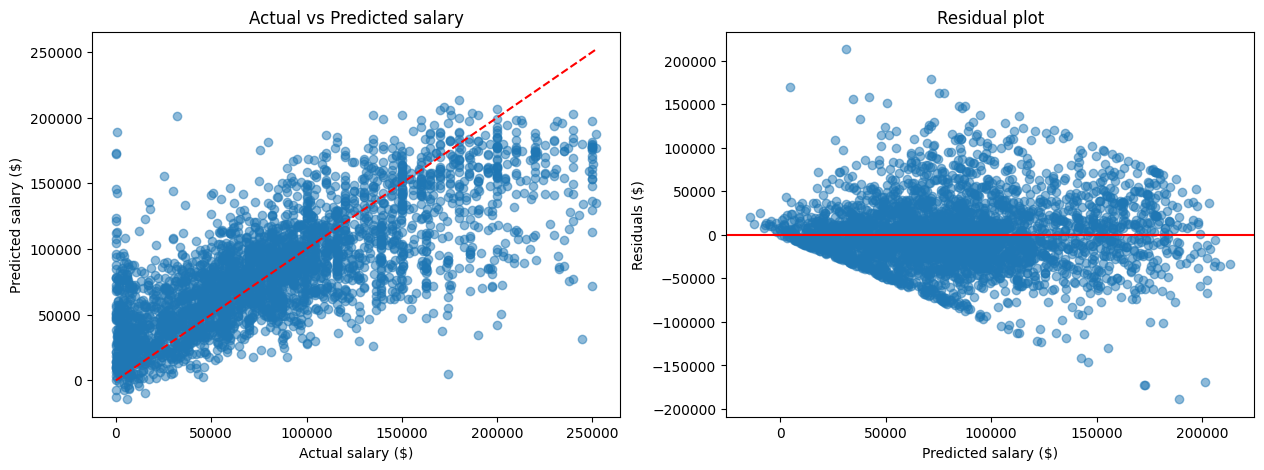

In [ ]:
model = GradientBoostingRegressor(**grid1.best_params_)
build_model(model,'GB Regressor + GridSearch', X_train, X_test, y_train, y_test,chart=1)

*   **the model captures the general trend, but struggles to accurately predict medium (~$150k) and high salaries**
*   **as salary increases, residuals decrease and become more negative, indicating growing error and heteroscedasticity**
* **for higher salaries the model tends to underestimate, while for lower salaries it often overestimates**

## Random Forest + GridSearch

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
param2 = {'n_estimators':[100,200],
         'min_samples_leaf': [1, 2],
         'max_depth': [None,20]}

In [ ]:
model = RandomForestRegressor()
grid_r = grid_search(model, param2)
model = RandomForestRegressor(**grid_r.best_params_)
build_model(model,'Random Forest + GridSearch', X_train, X_test, y_train, y_test,chart=0)

Best score: 0.5187990844031293 using parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
--- Model -> Random Forest + GridSearch---
Evaluation - Training set
R2 score : 0.89
MAE score : 13,199.95 $

Evaluation - Test set
R2 score : 0.54
MAE score : 29,415.59 $


## Gradient Boosting - GridSearch + Feature Importance

Text(0.5, 1.0, 'Top 20 most important features')

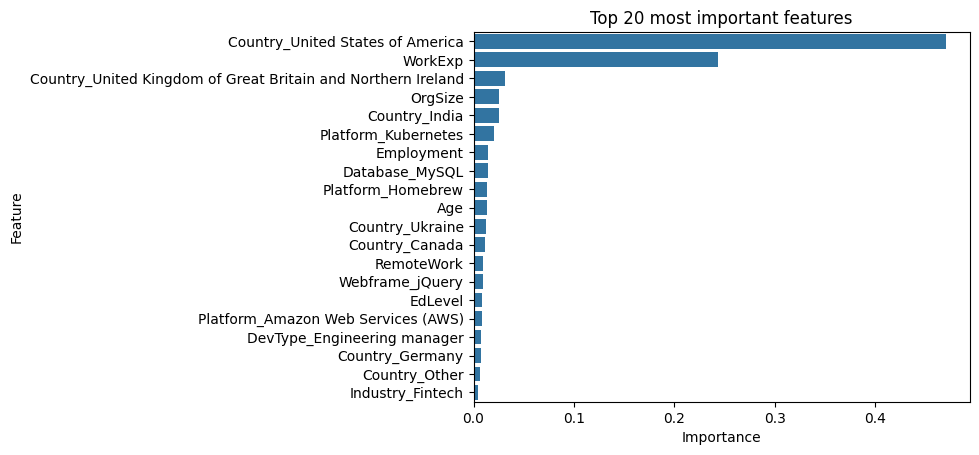

In [ ]:
feature_importance = gbr.feature_importances_
feature_importance_df = pd.DataFrame({'Feature':X.columns, 'Importance':gbr.feature_importances_})
top20 = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)
sns.barplot(top20, x='Importance', y='Feature')
plt.title('Top 20 most important features')

*   **7 out of the top 20 features are location-based, indicating a strong geographic influence on salary**
*   **the most impactful factors are being located in the USA and work experience**
* **other features (such as organisation size, platforms, employment, age) have significantly lower impact**



In [ ]:
data_top = data[top20['Feature']]
X_train,X_test,y_train,y_test = train_test_split(data_top,y,test_size=0.2, random_state=42)

gbr2= GradientBoostingRegressor()
gbr2.fit(X_train, y_train)
grid2 = grid_search(gbr2,param)

Best score: 0.5227709641968801 using parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 500}


In [ ]:
model = GradientBoostingRegressor(**grid2.best_params_)
build_model(model,'GB Regressor + GridSearch + FeatureImportance', X_train, X_test, y_train, y_test,chart=0)

--- Model -> GB Regressor + GridSearch + FeatureImportance---
Evaluation - Training set
R2 score : 0.54
MAE score : 28,980.78 $

Evaluation - Test set
R2 score : 0.55
MAE score : 29,331.17 $


# Evaluation

In [ ]:
results.sort_values(by='Model')

,Model,R2 train,R2 test,MAE test,RMSE test
0,Baseline,-0.02,-0.03,46954.58,59808.57
3,GB Regressor + GridSearch,0.61,0.56,28679.38,38933.71
5,GB Regressor + GridSearch + FeatureImportance,0.54,0.55,29331.17,39660.18
2,Gradient Boost Regressor,0.55,0.54,29483.97,39811.62
1,Linear Regression,0.52,0.53,30022.73,40230.34
4,Random Forest + GridSearch,0.89,0.54,29415.59,39887.86


*   **The best performing model was the Gradient Boost Regressor with Grid Search, as it achieved the highest R2 scores and the lowest errors (MAE ~29k $)**

* **Compared to the baseline model (MAE ~47k $), it achieved significantly better accuracy in predicting salary**
*   **Linear Regression showed the weakest performance among the tested models (excluding the baseline), suggesting that the relationships in the data are not  linear**
* **Feature importance slightly worsens the Gradient Boost Regressor results, while Grid Search improves them**
* **Random Forest shows signs of overfitting (high R2 score on train data and lower on test data), which suggests that the model has memorized the training data and does not generalize well to unseen observations**






# Conclusions

*   **the analysis showed that the most important factors influencing salary are location (particularly being based in the United States) and years of professional experience. Other variables, such as company size, have a noticeably smaller impact on salary levels**
* **among the tested models, the best performance was achieved by the Gradient Boosting Regressor combined with Grid Search, which resulted in the highest predictive accuracy and the lowest error metrics**
* **other models had worse performence due to non-linear data (Linear Regression) or overfitting - achieving better results on trained than unseen data (Random Forest)**
*   **limitations: noisy data, the data is dominated by respondents with lower to mid-level salaries, resulting in a skewed salary distribution and limited representation of high earners. This makes accurate prediction of extreme salary values more difficult**
* **despite limitations, the models significantly outperform the baseline approach, indicating that salary can be predicted using the available features**

